# Import the data annotation json

In [3]:
import json
with open("../../../../data/ml/machine-and-movement_complete.json", "r") as f:
    annotation_json = json.load(f)

In [7]:
annotation_json

{'2': [{'label': 'Clamping',
   'start': 7.538760080645162,
   'end': 17.417321908602155,
   'duration': 9.878561827956993},
  {'label': 'Bending',
   'start': 17.476831317204304,
   'end': 40.14991599462366,
   'duration': 22.673084677419357},
  {'label': 'Mandrel Extraction',
   'start': 31.69957997311829,
   'end': 40.17967069892474,
   'duration': 8.480090725806448}],
 '3': [{'label': 'Clamping',
   'start': 7.538760080645162,
   'end': 17.32805779569893,
   'duration': 9.789297715053767},
  {'label': 'Bending',
   'start': 17.387567204301078,
   'end': 40.17967069892474,
   'duration': 22.79210349462366},
  {'label': 'Mandrel Extraction',
   'start': 31.640070564516137,
   'end': 40.17967069892474,
   'duration': 8.539600134408602}],
 '4': [{'label': 'Clamping',
   'start': 7.449495967741935,
   'end': 17.32805779569893,
   'duration': 9.878561827956993},
  {'label': 'Bending',
   'start': 17.417321908602155,
   'end': 40.209425403225815,
   'duration': 22.79210349462366},
  {'lab

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



# Convert nested dictionary to DataFrame
rows = []
for instance, events in annotation_json.items():
    for event in events:
        rows.append({
            'Instance': instance,
            'Label': event['label'],
            'Duration': event['duration']
        })

df = pd.DataFrame(rows)


Summary statistics per label:
                    count       mean       std        min        25%  \
Label                                                                  
Bending             315.0  23.164478  1.082957  20.939069  22.673085   
Clamping            316.0   9.920030  0.580304   0.000000   9.848807   
De-Clamping         260.0  22.281529  0.220506  21.536972  22.145114   
Mandrel Extraction  315.0   9.052158  0.305110   8.331317   8.848606   

                          50%        75%        max  
Label                                                
Bending             23.097043  24.138735  25.047103  
Clamping             9.934892  10.044597  10.550907  
De-Clamping         22.274409  22.389491  23.198579  
Mandrel Extraction   9.073558   9.260680   9.911458  


/tmp/ipykernel_33775/298313883.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Label', y='Duration', data=df, palette='Set2')


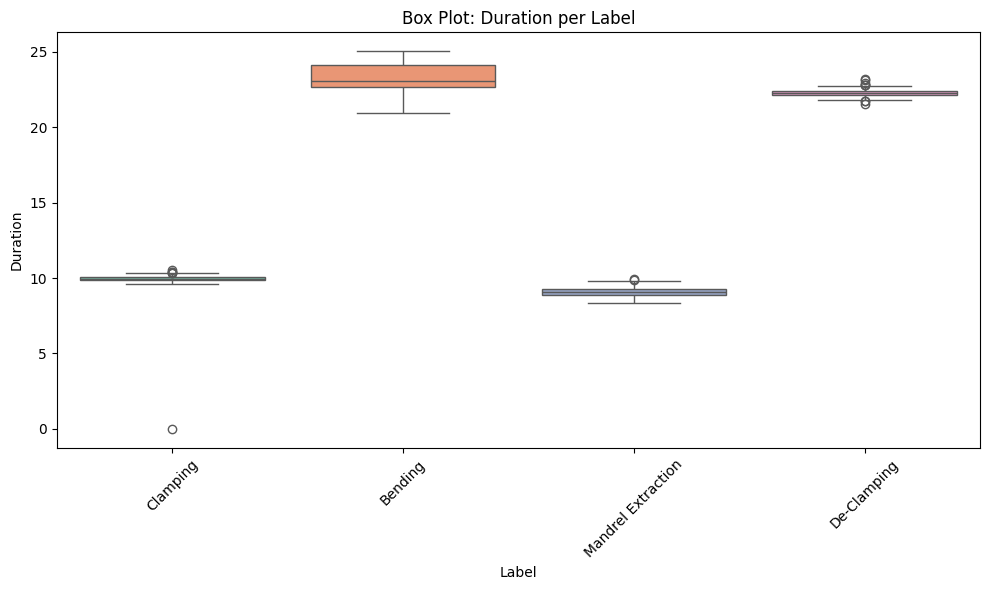

/tmp/ipykernel_33775/298313883.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Label', y='Duration', data=df, palette='Set3', inner='quartile')


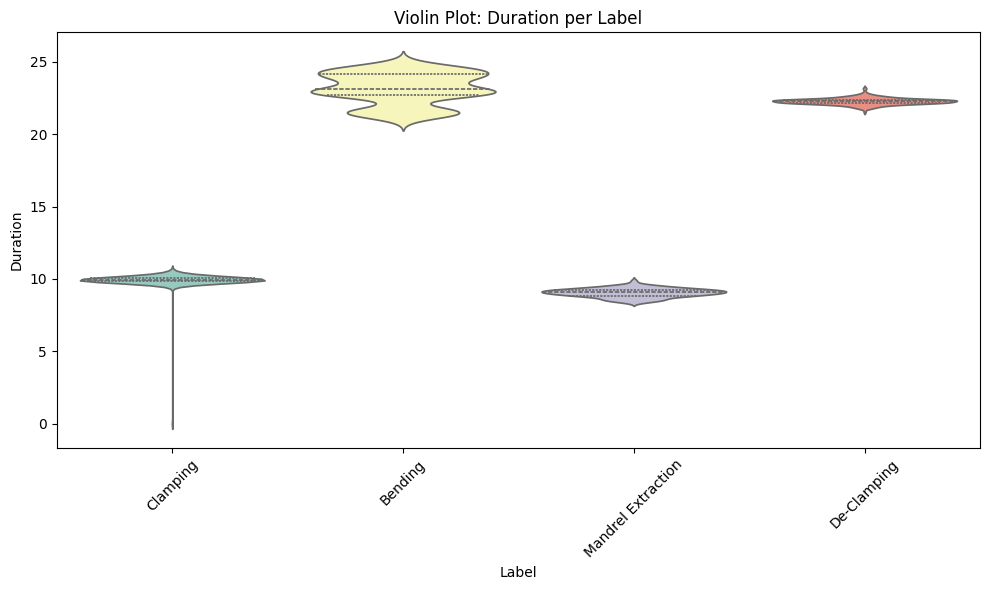

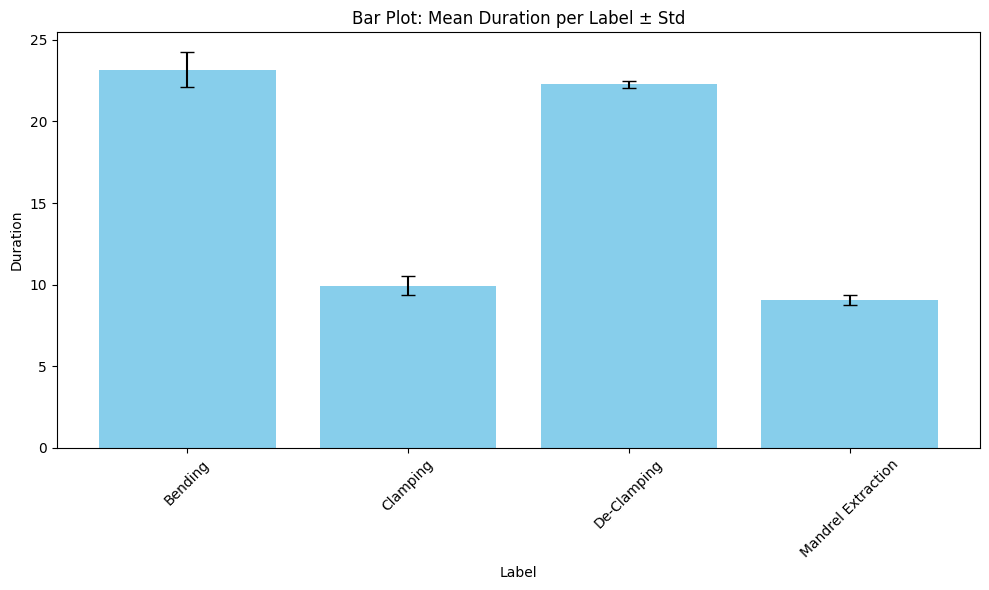

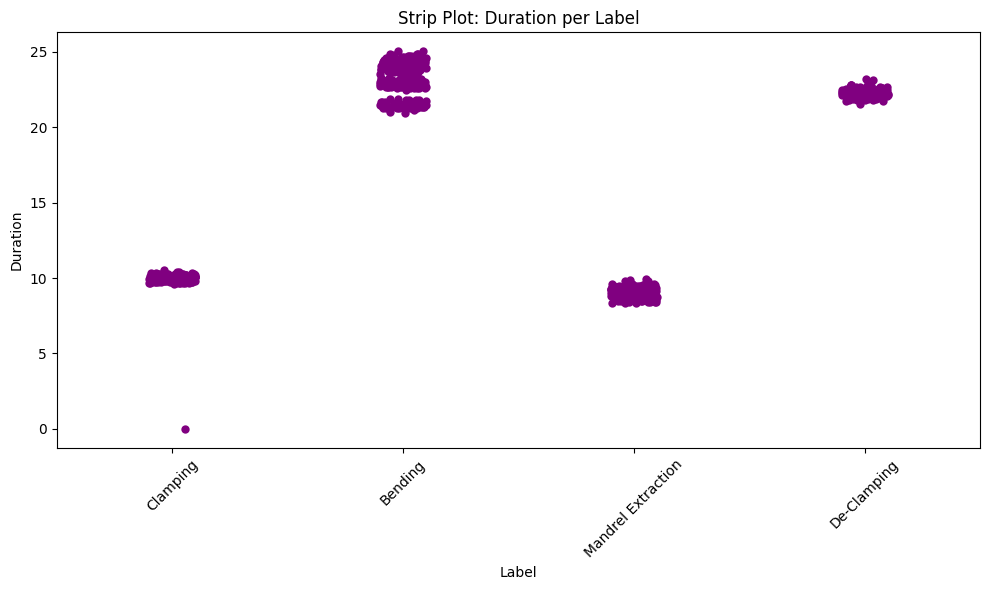

In [12]:
df = pd.DataFrame(rows)

# --- Summary Statistics ---
stats = df.groupby('Label')['Duration'].describe()
print("Summary statistics per label:")
print(stats)

# --- Box Plot ---
plt.figure(figsize=(10, 6))
sns.boxplot(x='Label', y='Duration', data=df, palette='Set2')
plt.title('Box Plot: Duration per Label')
plt.ylabel('Duration')
plt.xlabel('Label')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- Violin Plot ---
plt.figure(figsize=(10, 6))
sns.violinplot(x='Label', y='Duration', data=df, palette='Set3', inner='quartile')
plt.title('Violin Plot: Duration per Label')
plt.ylabel('Duration')
plt.xlabel('Label')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- Bar Plot (Mean ± Std) ---
mean_std = df.groupby('Label')['Duration'].agg(['mean', 'std']).reset_index()
plt.figure(figsize=(10, 6))
plt.bar(mean_std['Label'], mean_std['mean'], yerr=mean_std['std'], capsize=5, color='skyblue')
plt.title('Bar Plot: Mean Duration per Label ± Std')
plt.ylabel('Duration')
plt.xlabel('Label')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- Strip Plot / Swarm Plot ---
plt.figure(figsize=(10, 6))
sns.stripplot(x='Label', y='Duration', data=df, color='purple', jitter=True, size=6)
plt.title('Strip Plot: Duration per Label')
plt.ylabel('Duration')
plt.xlabel('Label')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
from utils.classification_utils import ClassifierPreprocessor
process_part ="machine_and_movement"
classifier_preprocessor = ClassifierPreprocessor(sensors_path=f"../../../../data/ml/features_{process_part}_complete.csv", annotation_json="../../../../data/ml/machine-and-movement_complete.json")
sensors_df, annotation_dict = classifier_preprocessor.read_data()
sensors_df = classifier_preprocessor.feature_selection()
sensors_df = classifier_preprocessor.assign_labels()

In [15]:
sensors_df

,Experiment_ID,MACHINE_BEND-DIE_LATERAL_Max_Torque_[%],MACHINE_BEND-DIE_ROTATING_Max_Torque_[%],MACHINE_BEND-DIE_VERTICAL_Max_Torque_[%],MACHINE_CLAMP-DIE_LATERAL_Max_Torque_[%],MACHINE_COLLET_AXIAL_Max_Torque_[%],MACHINE_MANDREL_AXIAL_Max_Torque_[%],MACHINE_PRESSURE-DIE_LATERAL_Max_Torque_[%],BEND-DIE_LATERAL_Movement_[mm],BEND-DIE_ROTATING_Angle_[°],CLAMP-DIE_LATERAL_Movement_[mm],COLLET_AXIAL_Movement_[mm],MANDREL_AXIAL_Movement_[mm],PRESSURE-DIE_AXIAL_Movement_[mm],Label
Time_[s],,,,,,,,,,,,,,,
0.00,2,0.000000,0.998974,0.011236,0.000725,0.848229,0.998051,1.000000,0.668790,1.000000,0.000000,0.000013,0.999988,0.205862,No Label
0.05,2,0.000000,0.998974,0.000000,0.000725,0.848843,0.998051,0.989675,0.668790,1.000000,0.000000,0.000009,0.999988,0.205862,No Label
0.10,2,0.000000,0.998974,0.011236,0.000725,0.849996,0.996101,0.916254,0.668790,1.000000,0.000000,0.000009,0.999988,0.205862,No Label
0.15,2,0.002375,0.998974,0.011236,0.000725,0.849151,0.998051,0.756844,0.668790,1.000000,0.000000,0.000013,0.999988,0.205862,No Label
0.20,2,0.000000,0.998974,0.000000,0.000725,0.848459,0.996101,0.603581,0.668790,1.000000,0.000000,0.000005,0.999988,0.205862,No Label
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86.30,318,0.074380,0.930169,0.250000,0.378455,0.891258,0.923232,0.785719,0.000004,0.998132,0.000002,0.999995,0.000000,0.000037,No Label
86.35,318,0.074380,0.926942,0.250000,0.378455,0.890637,0.923232,0.785708,0.000004,0.998791,0.000002,0.999996,0.000000,0.000037,No Label
86.40,318,0.076446,0.931930,0.250000,0.378455,0.891810,0.923232,0.785636,0.000004,0.999315,0.000002,0.999995,0.000000,0.000037,No Label
